In [ ]:
# Homework 3
## Statistical Learning and Prediction
This implements K-Means clustering, K-Nearest Neighbors classification, and Change Point Analysis using Fitbit activity data.

In [2]:
import os
os.listdir()

['.virtualenvs',
 'dailySteps.csv',
 'hourlyIntensities.csv',
 '.local',
 '.ipynb_checkpoints',
 '.pythonstartup.py',
 'dailyCalories.csv',
 '.ipython',
 'minuteCalories.csv',
 'README.ipynb',
 'hourlySteps.csv',
 '.gitconfig',
 '.vimrc',
 'hourlyCalories.csv',
 'dailyIntensities.csv',
 'minuteMETs.csv',
 '.profile',
 'anaconda_projects',
 '.jupyter',
 'HW3.ipynb',
 '.anaconda',
 'minuteSteps.csv',
 '.npm',
 '.conda',
 'minuteIntensities.csv',
 '.bashrc']

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [23]:
def kmeans(X, k, iterations=10):

    # randomly choose k data points as the starting cluster centroids
    indices = np.random.choice(len(X), k, replace=False)
    centroids = X[indices]

    # repeat the clustering process several times to improve cluster placement
    for _ in range(iterations):

        # create an empty list for each cluster
        clusters = [[] for _ in range(k)]

        # go through every point in the dataset
        for point in X:

            # compute the distance from this point to every centroid
            distances = [np.linalg.norm(point - c) for c in centroids]

            # find the centroid with the smallest distance
            cluster_index = np.argmin(distances)

            # assign this point to that cluster
            clusters[cluster_index].append(point)

        # we recompute the centroid locations
        new_centroids = []

        for cluster in clusters:

            # if a cluster has points, compute the new centroid as the mean
            if len(cluster) > 0:
                new_centroids.append(np.mean(cluster, axis=0))

            # if a cluster accidentally becomes empty,keep the old centroid position
            else:
                new_centroids.append(centroids[len(new_centroids)])

        # update centroid positions
        centroids = np.array(new_centroids)

    # return both the cluster groups and their centroid locations
    return clusters, centroids

In [ ]:
The k-means algorithm groups unlabeled data into clusters based on distance to cluster centroids.
Each point is assigned to the nearest centroid, and centroids are updated iteratively until convergence.

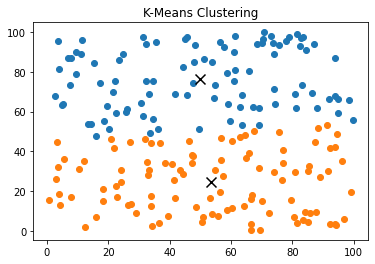

In [24]:
# generate sample data
X = np.random.rand(200,2)*100

clusters, centroids = kmeans(X,2)

# plot
for cluster in clusters:
    cluster = np.array(cluster)
    plt.scatter(cluster[:,0], cluster[:,1])

plt.scatter(centroids[:,0],centroids[:,1],color='black',marker='x',s=100)
plt.title("K-Means Clustering")
plt.show()

In [25]:
def knn(train_X, train_y, k, new_point):

    # create a list to store distances and labels
    distances = []

    # compute distance from the new point to every training sample
    for i in range(len(train_X)):

        d = np.linalg.norm(train_X[i] - new_point)

        # store the distance and corresponding label
        distances.append((d, train_y[i]))

    # sort all distances from smallest to largest
    distances.sort(key=lambda x: x[0])

    # select the first k nearest neighbors
    neighbors = distances[:k]

    # extract the labels of these neighbors
    labels = [label for _, label in neighbors]

    # return the most common label among the neighbors
    return max(set(labels), key=labels.count)

In [27]:
train_X = np.array([[2,3],[3,4],[5,6],[7,8],[8,8]])
train_y = np.array(["A","A","B","B","B"])

# new point we want to classify
new_point = np.array([4,5])

# run the knn classifier
prediction = knn(train_X, train_y, 3, new_point)

print("Predicted class:", prediction)

Predicted class: A


In [ ]:
KNN is a supervised learning algorithm that classifies a new data point
based on the majority label among its k nearest neighbors.

In [28]:
def cpa(x, K=1000):
    

   # convert to numpy array
    x = np.array(x)

    # compute the average value of the dataset
    mean_x = np.mean(x)

    # subtract the mean to compute the error signal
    epsilon = x - mean_x

    # compute cumulative sum of the errors
    y = np.cumsum(epsilon)

    # compute the range of this cumulative signal
    R_original = np.max(y) - np.min(y)

    # identify the point with the largest deviation
    cp_index = np.argmax(np.abs(y))

    # store ranges from bootstrap simulations
    R_boot = []

    # repeat bootstrap many times
    for _ in range(K):

        # randomly shuffle the data
        shuffled = np.random.permutation(x)

        # recompute error signal
        eps = shuffled - np.mean(shuffled)

        # cumulative error
        y_boot = np.cumsum(eps)

        # store its range
        R_boot.append(np.max(y_boot) - np.min(y_boot))

    R_boot = np.array(R_boot)

    # compute confidence level
    confidence = np.sum(R_boot < R_original)/K

    return cp_index, confidence

In [29]:
# load the Fitbit daily steps dataset
steps = pd.read_csv("dailySteps.csv")

# remove zero-step days (days when device was not worn)
steps = steps[steps["StepTotal"] > 0]

# extract only the step counts
data = steps["StepTotal"].values

In [30]:
# run CPA on the daily steps data
cp, conf = cpa(data)

print("Detected Change Point:", cp)
print("Confidence:", conf)

Detected Change Point: 230
Confidence: 1.0


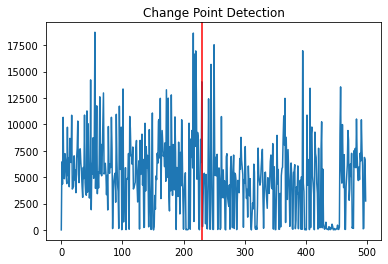

In [15]:
# plot the daily steps data
plt.plot(data)

# mark the detected change point
plt.axvline(cp,color='red')

plt.title("Change Point Detection in Daily Steps")
plt.xlabel("Time Index")
plt.ylabel("Steps")
plt.show()

In [31]:
change_points = []

segment = data.copy()

for i in range(8):
    cp, conf = cpa(segment)

    if conf < 0.9:
        break

    change_points.append(cp)

    segment = segment[cp:]

print(change_points)

[230, 225]
